# Notebook for practical exercises | Week #5 Lesson #1

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Assessing Fairness and Bias*.

After this session, you will know how to analyze the results of a classification model regarding fairness on a real-world clinical problem:
* Comparing performance of a model across groups of population ;
* Implement a resampling and/or data augmentation strategy to mitigate biases ;
* Reporting fairness evaluation metrics.

## Dataset

We will use the [The Brain Resection Multimodal Imaging Database](https://www.cancerimagingarchive.net/collection/remind/) [1]. The Brain Resection Multimodal Imaging Database (ReMIND) contains pre- and intra-operative brain MRI collected on 114 consecutive patients who were surgically treated with image-guided tumor resection between 2018 and 2022.

[1] Juvekar, P., Dorent, R., Kögl, F., Torio, E., Barr, C., Rigolo, L., Galvin, C., Jowkar, N., Kazi, A., Haouchine, N., Cheema, H., Navab, N., Pieper, S., Wells, W. M., Bi, W. L., Golby, A., Frisken, S., & Kapur, T. (2023). The Brain Resection Multimodal Imaging Database (ReMIND) (Version 1) [dataset]. The Cancer Imaging Archive. [https://doi.org/10.7937/3RAG-D070](https://doi.org/10.7937/3RAG-D070)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import sys
from glob import glob
import warnings

warnings.filterwarnings(action="ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms
# from torchvision import tv_tensors

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

from PIL import Image
import pydicom

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import warnings
warnings.filterwarnings(action="ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import argparse
import math
import os
from glob import glob

!pip install -U segmentation-models-pytorch -q
import albumentations as A
import numpy as np
import pandas as pd
import SimpleITK as sitk
sitk.ProcessObject.SetGlobalWarningDisplay(False)
import torch
import torch.nn as nn
import torch.optim as optim
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


In [ ]:
import torch, torchvision; print(torch.__version__, torchvision.__version__)


2.7.1+cu126 0.22.1+cu126


### Download and load the data

If needed, run the following cells to download and unzip the dataset.

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [ ]:
DATA_PATH = './'

# !curl https://uni-bonn.sciebo.de/s/s1t8QUZ02MF1Qoh/download --output {DATA_PATH}/data.zip
# !unzip {DATA_PATH}/data.zip -d {DATA_PATH}

In [ ]:
# Load and observe available data
!curl https://uni-bonn.sciebo.de/s/rmXkeTTLSPPNz9i/download --output {DATA_PATH}/metadata.xlsx
clinical_df = pd.read_excel(f'{DATA_PATH}/metadata.xlsx')
clinical_df = clinical_df.loc[clinical_df['WHO Grade']!='Not assigned'] # we remove the unassigned grades
clinical_df # Print the first 5 and last 5 rows of the dataframe

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  115k  100  115k    0     0   417k      0 --:--:-- --:--:-- --:--:--  416k


,Case Number,Age,Sex,Race,Ethnicity,Laterality,Previous Craniotomy,WHO Grade,Histopathology,IDH-mutant,...,Gyral,Subgyral,Enhancement,T2/FLAIR hyperintensity,Tumor Location,Preoperative Tumor Volume,Awake Craniotomy,Preoperative MRI scanner,Tesla,Ultrasound Missing
0,1,41,Male,White,Not Hispanic,Right,No,3,Astrocytoma,Yes,...,Yes,Yes,No,Yes,"Right Anterior Temporal, Right Insular",27.278449,No,Siemens 3T Prisma,3,No
1,2,22,Female,White,Not Hispanic,Right,No,2,Astrocytoma,Yes,...,Yes,No,No,Yes,Paramedian Right Frontal,23.697855,No,Siemens 3T Prisma,3,No
2,3,30,Male,Asian,Not Hispanic,Left,No,2,Oligodendroglioma,Yes,...,Yes,No,No,Yes,Left Posterior Temporal,9.794235,Yes,"GE 1.5T Signa Excite HDxt (OSH T1), Siemens 3T...","3, 1.5",No
3,4,23,Male,White,Hispanic,Left,No,1,Dysembryoplastic neuroepithelial tumor,No,...,Yes,No,Yes,Yes,Left Inferior Parietal,2.099037,No,Siemens 3T Prisma,3,No
5,6,58,Male,White,Not Hispanic,Left,No,2,Astrocytoma,Yes,...,No,Yes,No,Yes,Left Insular,20.422339,No,"Siemens 3T Verio (T2), GE 1.5T Signa (OSH T1)","3, 1.5",No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,110,47,Male,White,Not Hispanic,Right,No,2,Oligodendroglioma,Yes,...,Yes,Yes,Yes,Yes,Right Parietal,29.921532,No,Siemens 3T Prisma,3,No
110,111,42,Female,White,Not Hispanic,Left,No,3,Astrocytoma,Yes,...,Yes,Yes,No,Yes,"Left Parietal, post-central strip",24.645000,No,Hitachi 1.16T(1.2T) Oasis,1.16,No
111,112,40,Female,Asian,Not Hispanic,Right,Yes,4,Astrocytoma,Yes,...,Yes,Yes,Yes,No,Right superficial frontal,42.875297,No,Siemens 1.5T Aera,1.5,No
112,113,50,Female,White,Not Hispanic,Right,Yes,4,Glioblastoma,No,...,Yes,Yes,Yes,No,Right Frontal,70.569160,No,GE 1.5T Signa Explorer,1.5,No


In this dataset, we have access to a few elements that allow us to group patient across categories, for instance:
* `Sex/Gender`
* `Age`
* `Race/Ethnicity`

We will first visualize the number of patients within each group.

<b>Q1.</b> What potential sources of bias do you see across categories, and which one is the less bias?

Next, let’s check the gender breakdown by grouping on Sex to see how many female vs. male patients we have.


In [ ]:
clinical_df.groupby(['Sex']).count()['Case Number']

Sex
Female    42
Male      52
Name: Case Number, dtype: int64

We have 42 female and 52 male patients—roughly a 45/55 split. This near‑balance reduces the risk of major gender imbalance skewing our model, but it’s still important to:

1. **Check performance by sex** (e.g., separate ROC/AUC, error rates) to ensure neither group suffers higher misclassification.  
2. **Consider calibration** across sexes, since even balanced class counts can hide differences in score distributions.  
3. **Plan mitigation** (re‑weighting, threshold adjustment, or fairness‑aware algorithms) if we detect systematic differences in error rates or predictive confidence between females and males.  


Explore the min and max Age of the patients

In this context, bins are used to discretize the continuous variable 'Patient Age' into distinct categories. You can treat age as a categorical protected attribute and assess whether the model performs similarly for younger and older patients (or whichever age bins you define).

In [ ]:
print("Age -> max, min:",int(clinical_df['Age'].max()), ",",int(clinical_df['Age'].min()))

Age -> max, min: 76 , 20


Define a fairness criterion for the age groups


<Axes: >

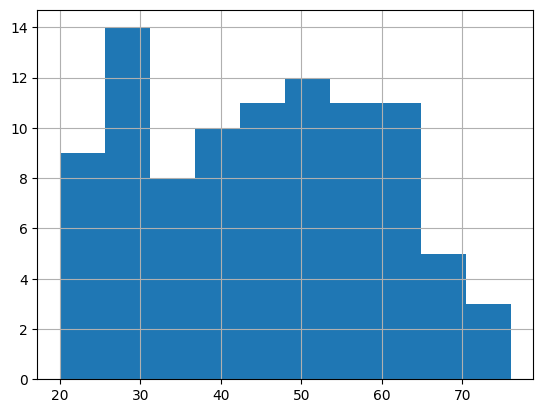

In [ ]:
clinical_df['Age'].hist()

We’ll simplify age into two groups—“<50” vs. “50+”—to see how many younger versus older patients we have, then tally the counts per bin.

In [ ]:
bins = [0, 50, 100]
labels = ['<50', '50+']
clinical_df['Age Group'] = pd.cut(clinical_df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)
clinical_df.groupby(['Age Group']).count()['Case Number']

Age Group
<50    57
50+    37
Name: Case Number, dtype: int64

Our cohort splits into 57 patients under 50 and 37 aged 50 or older. This gives us a reasonably balanced younger vs. older comparison. Later, we’ll check if our classifier behaves differently across these age bins (e.g. disparate error rates).


Let's explore the Ethnicity now:

In [ ]:
clinical_df.groupby(['Ethnicity']).count()['Case Number']

Ethnicity
Declined         1
Hispanic         4
Not Hispanic    89
Name: Case Number, dtype: int64

Right away we see a stark imbalance: over 95% of patients are labeled “Not Hispanic,” while Hispanic patients make up only about 4% and one patient declined to state their ethnicity. This raises several questions:

1. **Sampling bias**  
   - Does the study location or recruitment process inadvertently favor non‑Hispanic patients?  
   - Are there barriers (e.g., language, access, consent processes) that deter Hispanic participants?

2. **Representation & fairness**  
   - With so few Hispanic cases, a model trained on this data may perform poorly for that group, leading to unequal errors (false positives or negatives).  
   - How would you measure fairness here? Should we look at error rates or calibration separately for each ethnicity?

3. **Data quality & missingness**  
   - The “Declined” category, though small, reminds us that missing or refused data can mask underlying patterns.  
   - Could the reasons for declining to disclose ethnicity correlate with other social factors that impact outcomes?

4. **Mitigation strategies**  
   - If adding more data isn’t feasible, should we consider re‑weighting or synthetic sampling to give more “voice” to underrepresented groups?  
   - Are there fairness‑aware algorithms or post‑hoc adjustments (e.g., equalized odds) we can apply?


An example of *Human and structural factors* that could bake bias into the data is to define:

- **high_grade = 1** for aggressive tumors (WHO Grade IV)  
- **high_grade = 0** for all other grades (I–III)

This simplifies our modeling understanding, lets us inspect class balance, and enables us to compute fairness metrics (e.g. difference in false positive rates) on a common binary outcome.  After binarization we’ll print out the value counts to see how many low‑ vs. high‑grade cases we have in our cohort.


In [ ]:
clinical_df["WHO Grade"].value_counts()

WHO Grade
4    37
2    31
3    23
1     3
Name: count, dtype: int64

Make sure your data is on the same type str

In [ ]:
grades = pd.to_numeric(
    clinical_df["WHO Grade"].astype(str).str.strip(),
    errors="coerce"
)

We want to binarize the pathology labels of the dataset to either `0` or `1` Now well make a decision on which it we use the `greater than or equal to` comparison element-wise. `i.e. >=3`

In [ ]:
clinical_df.loc[:, "Pathology Grade"] = (grades >= 3).astype(int)# (>=3 → 1, else 0)
clinical_df["Pathology Grade"].value_counts()

Pathology Grade
1    60
0    34
Name: count, dtype: int64

In [ ]:
clinical_df[['Age Group', 'Sex','Ethnicity','Pathology Grade']]

,Age Group,Sex,Ethnicity,Pathology Grade
0,<50,Male,Not Hispanic,1
1,<50,Female,Not Hispanic,0
2,<50,Male,Not Hispanic,0
3,<50,Male,Hispanic,0
5,50+,Male,Not Hispanic,0
...,...,...,...,...
109,<50,Male,Not Hispanic,0
110,<50,Female,Not Hispanic,1
111,<50,Female,Not Hispanic,1
112,<50,Female,Not Hispanic,1


In [ ]:
clinical_df.groupby(['Age Group', 'Ethnicity', 'Pathology Grade',]).count()['Case Number']

Age Group  Ethnicity     Pathology Grade
<50        Declined      0                   1
                         1                   0
           Hispanic      0                   2
                         1                   0
           Not Hispanic  0                  22
                         1                  32
50+        Declined      0                   0
                         1                   0
           Hispanic      0                   0
                         1                   2
           Not Hispanic  0                   9
                         1                  26
Name: Case Number, dtype: int64

Prevalence by Age and Ethnicity (ground‑truth “Demographic Parity”)

In [ ]:
prev = clinical_df.groupby(['Age Group','Ethnicity'])['Pathology Grade'].mean()
print(prev)

Age Group  Ethnicity   
<50        Declined        0.000000
           Hispanic        0.000000
           Not Hispanic    0.592593
50+        Declined             NaN
           Hispanic        1.000000
           Not Hispanic    0.742857
Name: Pathology Grade, dtype: float64


What this means

- 0.5926 for <50 & “Not Hispanic” means 59% of those under 50 who are non‑Hispanic have high‑grade tumors.

- 0.00 for <50 & Hispanic (and Declined) means none of those few younger Hispanic (or “Declined”) had high grade.

- 1.00 for 50+ & Hispanic means 100% of the two older Hispanic patients were high grade.

- 0.7429 for 50+ & non‑Hispanic means 74% of the older non‑Hispanics are high grade.

- NaN for 50+ & Declined simply means no patients in that cell, so you can’t compute a proportion.

With this code we will pick out one slice per case—the axial slice with the largest tumor mask area

### Dataset split


<div class="alert alert-block alert-info">
<b>Q2.</b> Split the dataset using the <code>train_test_split</code> function from scikit-learn and create the three variables: <code>train_dataset</code>, <code>val_dataset</code>, <code>test_dataset</code>.
</div>

To mitigate the effect of this imbalance as much as possible, we stratify the splitting to balance the repartition of labels across sets. The goal of this technique is to have similar proportions of labels across sets.

Specifically, we will use `train_test_split` with the `stratify` parameter on the 'Age Group' column to ensure that the proportion of patients in each age group is roughly the same across the training, validation, and test sets. This helps to ensure that our model is trained and evaluated on representative samples of each age group.

We will split the data with the following proportions:

- train: 70%
- validation: 10%
- test: 20%


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# First, split off the train set (70%) and temp_df (30%)
sss1 = StratifiedShuffleSplit(
    n_splits=1,
    train_size=0.70,
    test_size=0.30,
    random_state=42
)
for train_idx, temp_idx in sss1.split(clinical_df, clinical_df["Age Group"]):
    train_df = clinical_df.iloc[train_idx]
    temp_df  = clinical_df.iloc[temp_idx]

sss2 = StratifiedShuffleSplit(
    n_splits=1,
    train_size=0.333,   # this will be our val set
    test_size=0.667,    # this will be our test set
    random_state=42
)
for val_idx, test_idx in sss2.split(temp_df, temp_df["Age Group"]):
    val_df  = temp_df.iloc[val_idx]
    test_df = temp_df.iloc[test_idx]

# Define positibe and negative slices

Each row in `clinical_df` corresponds to one patient and contains two new columns:

- Pos Slices: a Python list of axial slice indices (z‑coordinates) where the tumor mask is sufficiently large (label = 1)

- Neg Slices: a list of slice indices where no mask is present (label = 0)

In [ ]:
#@title Store tumor 2D slice in dataframe
# Helper functions to read the dicom and reconstruct the mask in image space
def load_dicom_series_to_3d_image(series_path: str) -> sitk.Image:
    """Read a DICOM series (folder full of slices) into a 3‑D SimpleITK image."""
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(series_path)
    reader.SetFileNames(dicom_names)
    img = reader.Execute()
    return img

def reconstruct_mask_in_image_space(mask_sitk: sitk.Image, reference_image: sitk.Image) -> sitk.Image:
    """Resample *mask_sitk* into the physical space & grid of *reference_image*."""
    return sitk.Resample(
        mask_sitk,
        reference_image,
        sitk.Transform(),
        sitk.sitkNearestNeighbor,
        0,
        mask_sitk.GetPixelID(),
    )

# Constants: adjust these to change number of positives/negatives per patient
NUM_POS = 1  # e.g. pick _ positives
NUM_NEG = 1   # e.g. pick _ negatives
GAP_FRAC = 0.1  # fraction of volume depth to enforce as minimum gap
pix_ = 50 # number of minimum pixels

pos_list = []
neg_list = []

for case_num in clinical_df['Case Number']:
    idx = f"{int(case_num):03d}"

    # Load image & mask
    img_dirs  = glob(f"{DATA_PATH}/data/ReMIND/sub-{idx}/anat/T1w*")
    mask_glob = glob(f"{DATA_PATH}/data/ReMIND/sub-{idx}/seg/ReMIND-{idx}-preop-SEG-tumor-*.nrrd")
    if not img_dirs or not mask_glob:
        pos_list.append([])
        neg_list.append([])
        continue

    img_sitk = load_dicom_series_to_3d_image(img_dirs[0])
    img_np   = sitk.GetArrayFromImage(img_sitk)   # (Z, H, W)
    Z, H, W  = img_np.shape

    mask_orig = sitk.ReadImage(mask_glob[0])
    mask_sitk = reconstruct_mask_in_image_space(mask_orig, img_sitk)
    mask_np   = sitk.GetArrayFromImage(mask_sitk).astype(np.uint8)

    # Minimum required separation between picks
    min_gap = int(GAP_FRAC * Z)

    # Compute per-slice tumor areas
    slice_areas = mask_np.sum(axis=(1, 2))

    # 1) Positive slices (require >pix_ voxels)
    pos_idxs = np.where(slice_areas > pix_)[0]
    if pos_idxs.size >= NUM_POS:
        picks   = np.linspace(0, pos_idxs.size - 1, NUM_POS)
        raw_pos = pos_idxs[np.round(picks).astype(int)].tolist()
    else:
        raw_pos = pos_idxs.tolist()

    # Enforce spacing and limit to NUM_POS
    pos_sel = []
    for z in raw_pos:
        if all(abs(z - p) >= min_gap for p in pos_sel):
            pos_sel.append(z)
        if len(pos_sel) == NUM_POS:
            break
    # If too few, pad from raw_pos without spacing constraint
    for z in raw_pos:
        if len(pos_sel) == NUM_POS:
            break
        if z not in pos_sel:
            pos_sel.append(z)

    # 2) Negative slices: hard negatives around tumor
    neg_sel = []
    if pos_idxs.size > 0:
        start, end = pos_idxs.min(), pos_idxs.max()
        offset = 1
        while len(neg_sel) < NUM_NEG and (start - offset >= 0 or end + offset < Z):
            for z in (start - offset, end + offset):
                if 0 <= z < Z and slice_areas[z] == 0:
                    if all(abs(z - n) >= min_gap for n in neg_sel):
                        neg_sel.append(int(z))
                        if len(neg_sel) == NUM_NEG:
                            break
            offset += 1

    # 3) If still short, random negatives from interior (exclude first/last 5%)
    if len(neg_sel) < NUM_NEG:
        margin  = int(0.05 * Z)
        interior = np.arange(margin, Z - margin)
        all_neg = interior[slice_areas[margin:Z - margin] == 0]
        all_neg = np.setdiff1d(all_neg, neg_sel, assume_unique=True)
        np.random.shuffle(all_neg)
        for z in all_neg:
            if len(neg_sel) == NUM_NEG:
                break
            if all(abs(z - n) >= min_gap for n in neg_sel):
                neg_sel.append(int(z))

    # Record final selections
    pos_list.append(pos_sel[:NUM_POS])
    neg_list.append(neg_sel[:NUM_NEG])

# Assign back to DataFrame
clinical_df['Pos Slices'] = pos_list
clinical_df['Neg Slices'] = neg_list


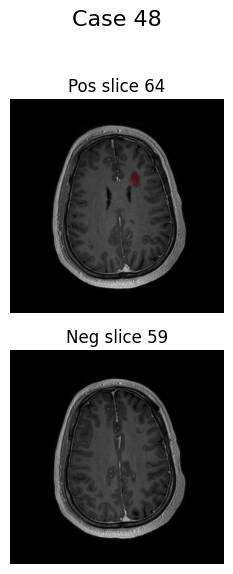

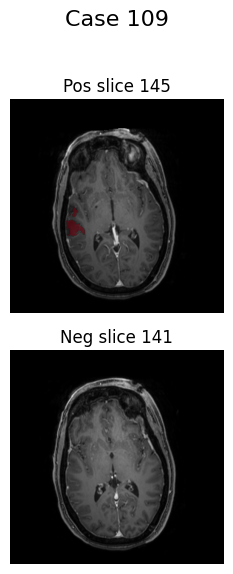

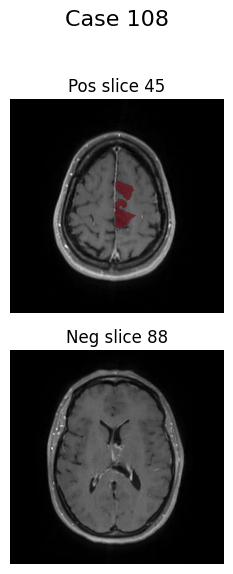

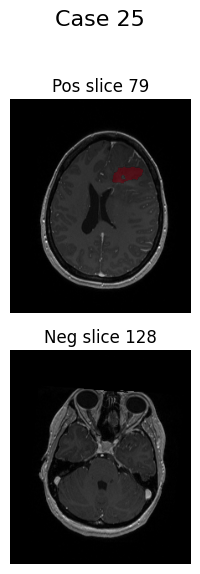

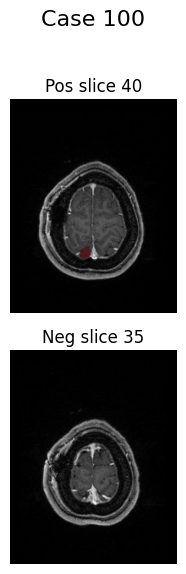

In [ ]:
#@title Visualize slices
import random
def visualize_pos_neg_slices(df, n_cases=2):
    """
    For randomly sampled n_cases from df, plot:
      - Row 0: a *randomized* ordering of the positive slices (with mask overlay)
      - Row 1: a *randomized* ordering of the negative slices (no mask overlay)
    Assumes df has 'Case Number', 'Pos Slices', 'Neg Slices' columns.
    """
    # pick random cases
    samples = df[df['Pos Slices'].map(len) > 0].sample(n_cases, random_state=42)

    for _, row in samples.iterrows():
        case_num = int(row['Case Number'])
        # copy and shuffle the slice lists
        pos_idxs = row['Pos Slices'][:]
        neg_idxs = row['Neg Slices'][:]
        random.shuffle(pos_idxs)
        random.shuffle(neg_idxs)

        idx_str = str(case_num).zfill(3)
        # load volume & mask
        img_dir   = glob(f"{DATA_PATH}/data/ReMIND/sub-{idx_str}/anat/T1w*")
        mask_glob = glob(
            f"{DATA_PATH}/data/ReMIND/sub-{idx_str}/seg/ReMIND-{idx_str}-preop-SEG-tumor-*.nrrd"
        )
        if not img_dir or not mask_glob:
            continue

        img_sitk  = load_dicom_series_to_3d_image(img_dir[0])
        img_np    = sitk.GetArrayFromImage(img_sitk)           # (Z, H, W)
        mask_orig = sitk.ReadImage(mask_glob[0])
        mask_sitk = reconstruct_mask_in_image_space(mask_orig, img_sitk)
        mask_np   = sitk.GetArrayFromImage(mask_sitk).astype(np.uint8)

        # determine grid size
        n_pos = len(pos_idxs)
        n_neg = len(neg_idxs)
        n_cols = max(n_pos, n_neg)

        fig, axes = plt.subplots(2, n_cols, figsize=(3*n_cols, 6))
        fig.suptitle(f'Case {case_num}', fontsize=16)

        # plot positives in randomized order
        for j in range(n_cols):
            ax = axes[0, j] if n_cols > 1 else axes[0]
            if j < n_pos:
                z = pos_idxs[j]
                img_slice  = img_np[z]
                mask_slice = mask_np[z]
                ax.imshow(img_slice, cmap='gray')
                # overlay mask
                masked = np.ma.masked_where(mask_slice == 0, mask_slice)
                ax.imshow(masked, cmap='Reds', alpha=0.6, vmin=0, vmax=1)
                ax.set_title(f'Pos slice {z}')
            ax.axis('off')

        # plot negatives in randomized order
        for j in range(n_cols):
            ax = axes[1, j] if n_cols > 1 else axes[1]
            if j < n_neg:
                z = neg_idxs[j]
                img_slice = img_np[z]
                ax.imshow(img_slice, cmap='gray')
                ax.set_title(f'Neg slice {z}')
            ax.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Example usage:
visualize_pos_neg_slices(train_df, n_cases=5)
# visualize_pos_neg_slices(val_df,   n_cases=5)
# visualize_pos_neg_slices(test_df,  n_cases=5)

Verify proportions

In [ ]:
print("Train:", train_df.shape, train_df["Age Group"].value_counts(), "\nproportion:",train_df["Age Group"].value_counts(normalize=True))
print("\nVal:  ", val_df.shape,   val_df["Age Group"].value_counts(), "\nproportion:",val_df["Age Group"].value_counts(normalize=True))
print("\nTest: ", test_df.shape,  test_df["Age Group"].value_counts(), "\nproportion:",test_df["Age Group"].value_counts(normalize=True))

Train: (65, 36) Age Group
<50    39
50+    26
Name: count, dtype: int64 
proportion: Age Group
<50    0.6
50+    0.4
Name: proportion, dtype: float64

Val:   (9, 36) Age Group
<50    6
50+    3
Name: count, dtype: int64 
proportion: Age Group
<50    0.666667
50+    0.333333
Name: proportion, dtype: float64

Test:  (20, 36) Age Group
<50    12
50+     8
Name: count, dtype: int64 
proportion: Age Group
<50    0.6
50+    0.4
Name: proportion, dtype: float64


Classification dataset that returns 2D image slices with a binary 'Tumor presence' target (0 or 1). Each slice from a patient is labeled with the patient's tumor flag.

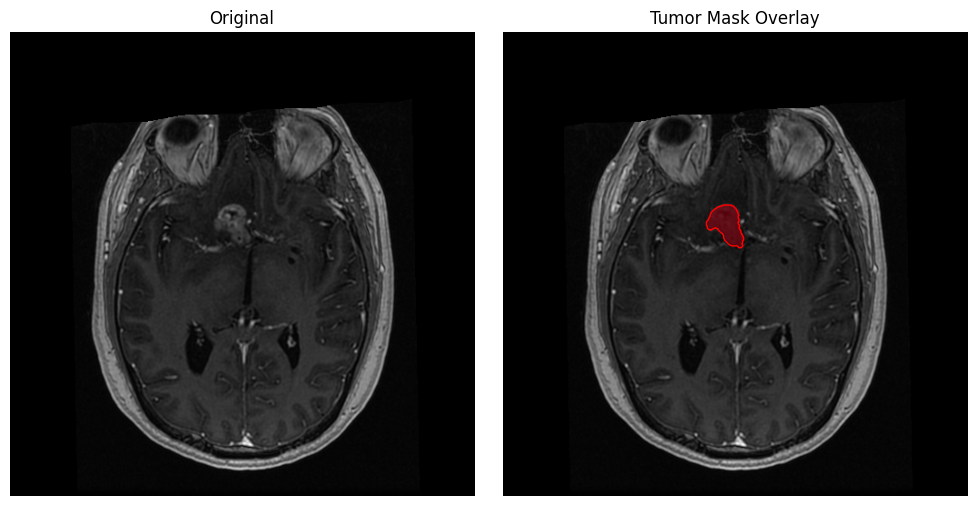

In [ ]:
#@title Visualize slice for a random case
import numpy as np
import SimpleITK as sitk
from glob import glob
import matplotlib.pyplot as plt


# Pick one random patient with a valid best slice
example = clinical_df.dropna(subset=['Best Slice']).sample(1).iloc[0]
case_num = int(example['Case Number'])
best_idx = int(example['Best Slice'])
idx      = str(case_num).zfill(3)
data_dir = DATA_PATH

# 1) Load the image
img_dir  = glob(f"{data_dir}/data/ReMIND/sub-{idx}/anat/T1w*")[0]
img_sitk = load_dicom_series_to_3d_image(img_dir)
img_np   = sitk.GetArrayFromImage(img_sitk)   # (Z, H, W)

# 2) Load & align the mask
mask_path = glob(
    f"{data_dir}/data/ReMIND/sub-{idx}/seg/ReMIND-{idx}-preop-SEG-tumor-*.nrrd"
)[0]
mask_orig = sitk.ReadImage(mask_path)
mask_sitk = reconstruct_mask_in_image_space(mask_orig, img_sitk)
mask_np   = sitk.GetArrayFromImage(mask_sitk).astype(np.uint8)

# 3) Overlay the pre‑computed best slice
img_slice  = img_np[best_idx]
mask_slice = mask_np[best_idx]


# assume img_slice and mask_slice are your 2D arrays
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Left: original
ax1.imshow(img_slice, cmap='gray')
ax1.axis('off')
ax1.set_title('Original')

# Right: overlay without white background
ax2.imshow(img_slice, cmap='gray')

# mask==0 → transparent, mask==1 → red
masked = np.ma.masked_where(mask_slice == 0, mask_slice)
ax2.imshow(
    masked,
    cmap='Reds',
    alpha=0.8,
    vmin=0,
    vmax=1
)

# contour around the mask
ax2.contour(
    mask_slice,
    levels=[0.5],
    colors='red',
    linewidths=1
)

ax2.axis('off')
ax2.set_title('Tumor Mask Overlay')

plt.tight_layout()
plt.show()


# Load previously trained model

For the task of classification in the ReMIND dataset we have trained a model on binary classification of tumor‐positive and tumor‐negative 2D slices.

We used a DenseNet‑121 backbone, pre‑trained on ImageNet, replacing its final fully‑connected classifier with a two‑output layer. The network was fine‑tuned on our curated slice dataset (10 positive and 10 negative slices per patient), using a patient‑wise 70/10/20 train/val/test split and a lightweight augmentation pipeline (random flips, shifts, Gaussian noise, coarse dropout, and ImageNet normalization). The pipeline can be found at the end of the notebook

Below we:

1. **Rebuild the model architecture** exactly as during training  
2. **Load** the saved weights from disk  
3. **Switch** to evaluation mode  
4. **Run inference** on the test set to verify the model's performance before the bias and fairness considerations. Namely we compute slice‑level accuracy and AUC, and then aggregate slice predictions into patient‑level scores


In [ ]:
#@title Classification Dataset definition
import cv2
class ClassificationDataset(Dataset):
    def __init__(self,
                 clinical_df: pd.DataFrame,
                 data_dir: str,
                 size: int = 512,
                 augment: bool = False):
        self.data_dir = data_dir
        self.size     = size

        mean = (0.485, 0.456, 0.406)
        std  = (0.229, 0.224, 0.225)

        if augment:
            transforms = [
                A.Resize(size, size, interpolation=cv2.INTER_LINEAR),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.ShiftScaleRotate(
                    shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5
                ),
                A.OneOf([
                    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50),
                    A.GridDistortion(num_steps=5, distort_limit=0.3),
                    A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05),
                ], p=0.2),
                A.RandomBrightnessContrast(brightness_limit=0.2,
                                          contrast_limit=0.2, p=0.2),
                A.RandomGamma(gamma_limit=(90, 110), p=0.1),
                A.GaussNoise(var_limit=(0.05, 0.09), p=0.1),
                A.CoarseDropout(max_holes=2,
                               max_height=int(size * 0.15),
                               max_width=int(size * 0.15),
                               fill_value=0, p=0.5),
                A.Normalize(mean=mean, std=std),
                ToTensorV2(),
            ]
        else:
            transforms = [
                A.Resize(size, size, interpolation=cv2.INTER_LINEAR),
                A.Normalize(mean=mean, std=std),
                ToTensorV2(),
            ]

        self.transform = A.Compose(
            transforms,
            additional_targets={'mask': 'mask'}
        )
        # Build sample list
        self.samples = []
        for _, row in clinical_df.iterrows():
            case = f"{int(row['Case Number']):03d}"
            img_dirs  = glob(f"{data_dir}/data/ReMIND/sub-{case}/anat/T1w*")
            mask_paths= glob(f"{data_dir}/data/ReMIND/sub-{case}/seg/ReMIND-{case}-preop-SEG-tumor-*.nrrd")
            if not img_dirs or not mask_paths:
                continue
            for z in row.get('Pos Slices', []):
                self.samples.append((case, int(z), 1))
            for z in row.get('Neg Slices', []):
                self.samples.append((case, int(z), 0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        case, z, label = self.samples[i]

        # 1) load image volume
        img_sitk = load_dicom_series_to_3d_image(
            glob(f"{self.data_dir}/data/ReMIND/sub-{case}/anat/T1w*")[0]
        )
        img_np   = sitk.GetArrayFromImage(img_sitk)  # (Z,H,W)

        # 2) load & align mask volume
        mask_sitk = reconstruct_mask_in_image_space(
            sitk.ReadImage(
                glob(f"{self.data_dir}/data/ReMIND/sub-{case}/seg/ReMIND-{case}-preop-SEG-tumor-*.nrrd")[0]
            ),
            img_sitk
        )
        mask_np = sitk.GetArrayFromImage(mask_sitk).astype(np.uint8)  # (Z,H,W)

        # 3) extract slice
        img_slice  = img_np[z]
        mask_slice = mask_np[z]  # 0/1

        # 4) stack to 3‑channels & scale to [0,1]
        img_3ch = np.stack([img_slice]*3, axis=-1).astype(np.float32)
        mn, mx = img_3ch.min(), img_3ch.max()
        img_3ch = (img_3ch - mn)/(mx - mn) if mx>mn else img_3ch*0

        # 5) feed both through the same transform
        augmented = self.transform(image=img_3ch, mask=mask_slice)
        img_t = augmented['image'].float()          # [3, size, size]
        mask_t= augmented['mask'].long()            # [size, size]

        return img_t, mask_t, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = ClassificationDataset(train_df, DATA_PATH, augment= True)
val_dataset = ClassificationDataset(val_df, DATA_PATH)
test_dataset = ClassificationDataset(test_df, DATA_PATH)

## Loading pretrained model  

In [ ]:
from torchvision.models import densenet121, DenseNet121_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load the best model
model = densenet121()
# replace head with 2 classes
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)
model.load_state_dict(torch.load('densenet121-mixedprecision-best.pth'))
model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Compare performance across genders

In [ ]:
def test(model, test_dataset, device):
    test_dataloader = DataLoader(test_dataset, batch_size=1)

    model.eval()
    model.to(device)

    preds_list = []
    probs_list = []
    label_list = []

    with torch.no_grad():
        for X, _, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)

            probs = nn.functional.softmax(out, dim=1)  # use softmax for multi-logit outputs
            preds = probs.argmax(dim=1)

            probs_list.append(probs[:, 1].item())  # probability for class 1
            preds_list.append(preds.item())
            label_list.append(y.detach().cpu().numpy())

    display = RocCurveDisplay.from_predictions(
    label_list,
    probs_list,
    name=f"Tumor vs. non-tumor",
    color="darkorange",
    plot_chance_level=True,
    )
    _ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Binary classification",
    )
    display.ax_.legend(frameon=False)

    print(
    f'Model EN-B0:',
    '\nAccuracy:', accuracy_score(label_list, preds_list),
    '\nF1-score:', f1_score(label_list, preds_list),
    '\nRecall:', recall_score(label_list, preds_list),
    '\nPrecision:', precision_score(label_list, preds_list)
    )

Model EN-B0: 
Accuracy: 0.5 
F1-score: 0.41379310344827586 
Recall: 0.35294117647058826 
Precision: 0.5


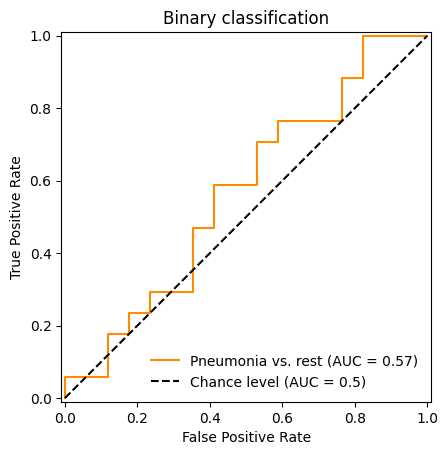

In [ ]:
test_dataset = ClassificationDataset(test_df, DATA_PATH)
test(model, test_dataset, device)

Model EN-B0: 
Accuracy: 0.5 
F1-score: 0.5 
Recall: 0.5 
Precision: 0.5


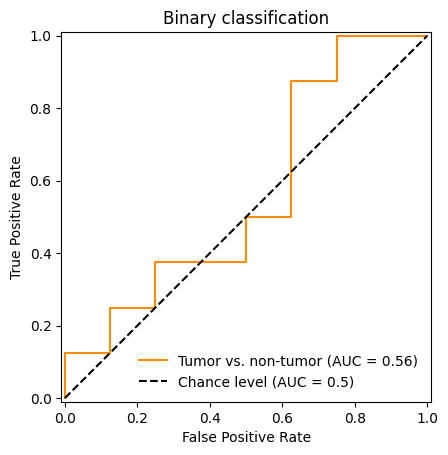

In [ ]:
test_dataset = ClassificationDataset(test_df.loc[test_df['Age Group']=='50+'], DATA_PATH)
test(model, test_dataset, device)

Model EN-B0: 
Accuracy: 0.5 
F1-score: 0.3076923076923077 
Recall: 0.2222222222222222 
Precision: 0.5


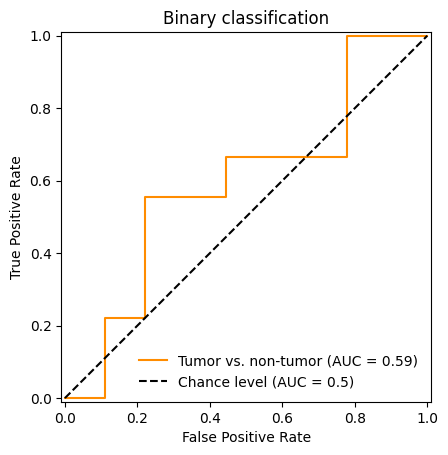

In [ ]:
test_dataset = ClassificationDataset(test_df.loc[test_df['Age Group']=='<50'], DATA_PATH)
test(model, test_dataset, device)

In [ ]:
from sklearn.metrics import confusion_matrix

def compute_AOD_EOD_from_split(y_true_F, y_pred_F, y_true_M, y_pred_M):
    # Helper to compute TPR and FPR
    def group_rates(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn + 1e-6)
        fpr = fp / (fp + tn + 1e-6)
        return tpr, fpr

    tpr_F, fpr_F = group_rates(y_true_F, y_pred_F)
    tpr_M, fpr_M = group_rates(y_true_M, y_pred_M)

    # Equal Opportunity Difference = |TPR_F - TPR_M|
    EOD = abs(tpr_F - tpr_M)

    # Average Odds Difference = 0.5 * (|FPR_F - FPR_M| + |TPR_F - TPR_M|)
    AOD = 0.5 * (abs(fpr_F - fpr_M) + EOD)

    return {
        'TPR_F': tpr_F,
        'TPR_M': tpr_M,
        'FPR_F': fpr_F,
        'FPR_M': fpr_M,
        'EOD': EOD,
        'AOD': AOD
    }

In [ ]:
def get_predictions_and_labels(model, dataframe, data_path, device):
    dataset = ClassificationDataset(dataframe, data_path)
    dataloader = DataLoader(dataset, batch_size=1)

    model.eval()
    model.to(device)

    results = []

    with torch.no_grad():
        for i in range(len(dataset)):
            img_t, mask_t, label_t = dataset[i]
            case, z, label = dataset.samples[i]

            img_t = img_t.unsqueeze(0).to(device)  # Add batch dimension

            out = model(img_t)
            probs = nn.functional.softmax(out, dim=1)  # use softmax for multi-logit outputs
            preds = probs.argmax(dim=1)

            results.append({
                'Case Number': int(case),
                'Slice Index': z,
                'True Label': label,
                'Prediction': preds.item(),
                'Probability_1': probs[:, 1].item()
            })

    return pd.DataFrame(results)

In [ ]:
slice_results_df = get_predictions_and_labels(model, test_df, DATA_PATH, device)

patient_predictions = slice_results_df.groupby('Case Number')['Probability_1'].mean().reset_index()
patient_predictions['Patient_Prediction'] = (patient_predictions['Probability_1'] >= 0.5).astype(int)

test_df_with_preds = pd.merge(test_df, patient_predictions[['Case Number', 'Patient_Prediction']], on='Case Number', how='left')
test_df_with_preds.dropna(subset=['Patient_Prediction'], inplace=True)


Separate true labels and patient-level predictions by sex

In [ ]:
test_df_F = test_df_with_preds.loc[test_df_with_preds['Sex'] == 'Female']
test_df_M = test_df_with_preds.loc[test_df_with_preds['Sex'] == 'Male']

binary_labels_F = test_df_F['Pathology Grade'].tolist()
binary_preds_F = test_df_F['Patient_Prediction'].tolist()

binary_labels_M = test_df_M['Pathology Grade'].tolist()
binary_preds_M = test_df_M['Patient_Prediction'].tolist()

Compute and print fairness metrics

In [ ]:
fairness_metrics = compute_AOD_EOD_from_split(binary_labels_F, binary_preds_F, binary_labels_M, binary_preds_M)
print(fairness_metrics)

{'TPR_F': np.float64(0.799999840000032), 'TPR_M': np.float64(0.0), 'FPR_F': np.float64(0.33333322222225925), 'FPR_M': np.float64(0.0), 'EOD': np.float64(0.799999840000032), 'AOD': np.float64(0.5666665311111456)}


## Pick your group

In [ ]:
# pick your protected attribute column here
PROTECTED_COL = 'Sex'   # or 'Ethnicity', etc.

# Build a dict: case_number(int) -> group(str or int)
case2group = (
    clinical_df
    .set_index('Case Number')[PROTECTED_COL]
    .to_dict()
)

# Optionally encode groups as ints
groups_unique = sorted(list(set(case2group.values())))
group2id = {g:i for i,g in enumerate(groups_unique)}


As the standard `ClassificationDataset` already constructs self.samples, we can just wrap it to capture and return group id:

In [ ]:
#@title GroupedDataset
class GroupedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, case2group, group2id):
        self.base = base_dataset
        self.case2group = case2group
        self.group2id = group2id

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask, y = self.base[idx]          # (img_t, mask_t, label)
        case_str, z, _ = self.base.samples[idx]
        case_num = int(case_str)
        g = self.case2group.get(case_num, None)
        g_id = self.group2id[g] if g is not None else -1
        return img, y, g_id

In [ ]:
train_dataset = ClassificationDataset(train_df, DATA_PATH, augment=True)
val_dataset   = ClassificationDataset(val_df,   DATA_PATH, augment=False)
test_dataset  = ClassificationDataset(test_df,  DATA_PATH, augment=False)

# wrap them
grouped_train = GroupedDataset(train_dataset, case2group, group2id)
grouped_val   = GroupedDataset(val_dataset,   case2group, group2id)
grouped_test  = GroupedDataset(test_dataset,  case2group, group2id)

# loaders
train_loader = DataLoader(grouped_train, batch_size=32, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(grouped_val,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(grouped_test,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


In [ ]:
from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model.load_state_dict(torch.load('densenet121-remind-best.pth', map_location=device))
model.to(device)
model.eval()


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
def eval_by_group(model, loader, device, num_groups):
    model.eval()
    y_true, y_pred, y_prob, g_all = [], [], [], []

    with torch.no_grad():
        for X, y, g in loader:
            X = X.to(device)
            logits = model(X)
            prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pred = (prob >= 0.5).astype(int)

            y_true.append(y.numpy())
            y_pred.append(pred)
            y_prob.append(prob)
            g_all.append(g.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    g_all  = np.concatenate(g_all)


    print(f"Overall accuracy: {(y_true == y_pred).mean():.4f}")

    # group metrics
    results = {}
    for gid in range(num_groups):
        mask = (g_all == gid)
        if mask.sum() == 0:
            continue
        yt = y_true[mask]
        yp = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        acc  = (tp + tn) / (tp + tn + fp + fn)
        tpr  = tp / (tp + fn + 1e-9)  # sensitivity/recall
        fpr  = fp / (fp + tn + 1e-9)
        ppv  = tp / (tp + fp + 1e-9)  # precision
        ppos = yp.mean()              # Demographic Parity rate

        results[gid] = dict(
            n=mask.sum(), acc=acc, tpr=tpr, fpr=fpr, ppv=ppv, ppos=ppos
        )
    return y_true, y_pred, y_prob, g_all, results

y_true, y_pred, y_prob, g_all, res = eval_by_group(model, val_loader, device, num_groups=len(groups_unique))
pd.DataFrame(res).T.assign(group=[groups_unique[g] for g in res.keys()]).set_index('group')


Overall accuracy: 0.5294


,n,acc,tpr,fpr,ppv,ppos
group,,,,,,
Female,6.0,0.500000,0.0,0.0,0.0,0.0
Male,11.0,0.545455,0.0,0.0,0.0,0.0


In [ ]:
def fairness_gaps(results):
    # results[gid] = {tpr, fpr, ppos, ...}
    tprs = [v['tpr'] for v in results.values()]
    fprs = [v['fpr'] for v in results.values()]
    ppos = [v['ppos'] for v in results.values()]

    eo_gap  = max(tprs) - min(tprs) + max(fprs) - min(fprs)  # Equalized Odds: sum TPR/FPR ranges
    dp_gap  = max(ppos) - min(ppos)                          # DP: rate of positive predictions
    return eo_gap, dp_gap

eo_gap, dp_gap = fairness_gaps(res)
print(f"Equalized Odds gap (TPR+FPR span): {eo_gap:.3f}")
print(f"Demographic Parity gap (rate span): {dp_gap:.3f}")


## Mitigation strategy

Build a per-sample weight for the *train* split. Give each (group, y) a weight inversely proportional to its frequency. A `WeightedRandomSampler` for class balance can be extended to group×label:

In [ ]:
labels  = []
groups  = []
for _, y, g_id in grouped_train:   # Correctly unpack img, y, and g_id
    labels.append(y.item())
    groups.append(g_id)  # g_id is already an int, no need for .item()

labels  = np.array(labels)
groups  = np.array(groups)

# count by (group, label)
from collections import Counter
pair_counts = Counter(zip(groups, labels))
weights = np.array([1.0 / pair_counts[(g,l)] for g,l in zip(groups, labels)], dtype=np.float32)

sampler = torch.utils.data.WeightedRandomSampler(
    weights, num_samples=len(weights), replacement=True
)

train_loader = DataLoader(grouped_train, batch_size=batch_size, sampler=sampler,
                          num_workers=8, pin_memory=True, persistent_workers=True)

## Post‑processing thresholds (no retraining)

Fit per‑group thresholds to equalize TPR or FPR on the validation set. Then apply them to test.

In [ ]:
#@title Utils
def fit_group_thresholds(y_true, y_prob, g_all, target='tpr', desired=None):
    """
    For each group, pick a threshold so that TPR (or FPR) matches a target value
    (e.g., the global mean or a chosen reference group). Simple grid-search for clarity.
    """
    thresholds = {}
    for gid in np.unique(g_all):
        mask = (g_all == gid)
        yt   = y_true[mask]
        yp   = y_prob[mask]
        best_thr = 0.5
        best_gap = 1e9

        # desired could be global target, otherwise use mean of group’s ROC best point
        if desired is None:
            # aim for group's own Youden index threshold as baseline
            desired = None

        for thr in np.linspace(0,1,201):
            pred = (yp >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(yt, pred, labels=[0,1]).ravel()
            tpr = tp/(tp+fn+1e-9)
            fpr = fp/(fp+tn+1e-9)
            metric = tpr if target=='tpr' else fpr
            gap = abs(metric - desired) if desired is not None else -tpr+fpr  # customize
            if gap < best_gap:
                best_gap, best_thr = gap, thr
        thresholds[gid] = best_thr
    return thresholds

# equalize TPR to the global TPR
global_tpr = res[next(iter(res))]['tpr']
ths = fit_group_thresholds(y_true, y_prob, g_all, target='tpr', desired=global_tpr)

# Apply per-group thresholds to TEST
def apply_group_thresholds(model, loader, device, thresholds):
    model.eval()
    preds, trues, groups = [], [], []
    with torch.no_grad():
        for X, y, g in loader:
            X = X.to(device)
            p = torch.softmax(model(X), 1)[:,1].cpu().numpy()
            g = g.numpy()
            pred = np.zeros_like(p, dtype=int)
            for gid in np.unique(g):
                thr = thresholds.get(gid, 0.5)
                pred[g==gid] = (p[g==gid] >= thr).astype(int)
            preds.append(pred)
            trues.append(y.numpy())
            groups.append(g)
    return np.concatenate(trues), np.concatenate(preds), np.concatenate(groups)

In [ ]:
y_t, y_p, g_t = apply_group_thresholds(model, test_loader, device, ths)

# Training pipeline

In [ ]:
#@title Split dataset
from sklearn.model_selection import train_test_split

# get all unique case IDs and their labels
case_nums = clinical_df['Case Number'].unique()
labels    = clinical_df.set_index('Case Number')['Pathology Grade'].loc[case_nums]

# first split: 70% train, 30% temp (val+test)
train_cases, temp_cases = train_test_split(
    case_nums,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# second split of the temp set: 10% val, 20% test
# Since temp is 30% of total, to get val=10% total we need val = 1/3 of temp
val_cases, test_cases = train_test_split(
    temp_cases,
    test_size=2/3,                # 2/3 of temp → 20% total
    stratify=labels.loc[temp_cases],
    random_state=42
)

# build the DataFrames

train_df = clinical_df[clinical_df['Case Number'].isin(train_cases)].reset_index(drop=True)
val_df   = clinical_df[clinical_df['Case Number'].isin(val_cases)].reset_index(drop=True)
test_df  = clinical_df[clinical_df['Case Number'].isin(test_cases)].reset_index(drop=True)
temp_df  = clinical_df[clinical_df['Case Number'].isin(temp_cases)].reset_index(drop=True)

# sanity check
print("Patients per split:",
      len(train_df['Case Number'].unique()), "train /",
      len(val_df['Case Number'].unique()),   "val /",
      len(test_df['Case Number'].unique()),  "test",
      len(temp_df['Case Number'].unique()),  "temp")


Patients per split: 75 train / 6 val / 13 test 19 temp
Class balance (grade=1) per split:
  train: 0.64
   val : 0.6666666666666666
  test : 0.6153846153846154


In [ ]:
#@title Training
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import densenet121, DenseNet121_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt

# -- Device setup --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# --- Mixed‑precision train & val loops ---
def train_loop(dataloader, model, loss_fn, optimizer, scaler, device):
    model.train()
    total_loss, correct, num_seen = 0.0, 0, 0

    for X, _, y in dataloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        # forward + backward in mixed precision
        with autocast():
            preds = model(X)
            loss  = loss_fn(preds, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = X.size(0)
        total_loss += loss.item() * batch_size
        correct    += (preds.argmax(1) == y).sum().item()
        num_seen   += batch_size

    avg_loss = total_loss / num_seen
    accuracy = correct / num_seen
    print(f"Val   → Acc: {100*accuracy:>5.2f}%, Loss: {avg_loss:.4f}")
    return avg_loss, accuracy

def val_loop(dataloader, model, loss_fn, device):
    model.eval()
    total_loss, correct, num_seen = 0.0, 0, 0

    with torch.no_grad():
        for X, _, y in dataloader:
            X, y = X.to(device), y.to(device)
            with autocast():
                preds = model(X)
                loss  = loss_fn(preds, y)

            batch_size = X.size(0)
            total_loss += loss.item() * batch_size
            correct    += (preds.argmax(1) == y).sum().item()
            num_seen   += batch_size

    avg_loss = total_loss / num_seen
    accuracy = correct / num_seen
    print(f"Validation → Acc: {100*accuracy:>5.2f}%, Loss: {avg_loss:.4f}")
    return avg_loss, accuracy

# --- Utility to plot at end ---
def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses,   label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Loss over Epochs"); plt.legend(); plt.grid(True)

    plt.figure()
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, val_accs,   label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs"); plt.legend(); plt.grid(True)

    plt.show()

# --- Hyperparams ---
learning_rate = 1e-3
batch_size    = 64
epochs        = 100
weight_decay  = 1e-4

# --- Model setup ---
weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

# replace head with 2 classes
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)

# freeze everything...
for p in model.parameters():
    p.requires_grad = False

# ...except last dense layer and classifier
for p in model.features.denseblock4.denselayer16.parameters():
    p.requires_grad = True
for p in model.classifier.parameters():
    p.requires_grad = True

model.to(device)

# --- DataLoaders ---
train_dataset = ClassificationDataset(train_df, DATA_PATH, augment=True)
val_dataset   = ClassificationDataset(val_df,   DATA_PATH, augment=False)

train_loader = DataLoader(
    temp_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True
)

# --- Loss, optimizer, scheduler, scaler ---
loss_fn  = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
scaler    = GradScaler()

# --- Training loop ---
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

best_val_acc = 0.0
best_epoch   = 0

start_time = time.time()
for epoch in range(1, epochs + 1):
    print(f"\n===== Epoch {epoch}/{epochs} =====")
    tr_loss, tr_acc = train_loop(train_loader, model, loss_fn, optimizer, scaler, device)
    vl_loss, vl_acc = val_loop(  val_loader,   model, loss_fn,           device)

    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    # save best
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_epoch   = epoch
        torch.save(model.state_dict(), 'densenet121-mixedprecision-best.pth')
        print(f"→ New best val acc: {100*best_val_acc:.2f}%")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} min — Best val acc {100*best_val_acc:.2f}% (epoch {best_epoch})")
torch.save(model.state_dict(), 'densenet121-mixedprecision-final.pth')

Using device: cuda

===== Epoch 1/100 =====
Val   → Acc: 56.67%, Loss: 0.7097
→ New best val acc: 56.67%

===== Epoch 2/100 =====
Val   → Acc: 54.00%, Loss: 0.7065

===== Epoch 3/100 =====
Val   → Acc: 58.00%, Loss: 0.6747
→ New best val acc: 58.00%

===== Epoch 4/100 =====
Val   → Acc: 59.33%, Loss: 0.6434
→ New best val acc: 59.33%

===== Epoch 5/100 =====
Val   → Acc: 55.33%, Loss: 0.6524

===== Epoch 6/100 =====
Val   → Acc: 61.33%, Loss: 0.6421
→ New best val acc: 61.33%

===== Epoch 7/100 =====
Val   → Acc: 66.67%, Loss: 0.6303
→ New best val acc: 66.67%

===== Epoch 8/100 =====
Val   → Acc: 64.67%, Loss: 0.6021

===== Epoch 9/100 =====
Val   → Acc: 58.67%, Loss: 0.6589

===== Epoch 10/100 =====
Val   → Acc: 60.00%, Loss: 0.5946

===== Epoch 11/100 =====
Val   → Acc: 62.67%, Loss: 0.5862

===== Epoch 12/100 =====
Val   → Acc: 66.67%, Loss: 0.5843

===== Epoch 13/100 =====
Val   → Acc: 66.67%, Loss: 0.5787

===== Epoch 14/100 =====
Val   → Acc: 65.33%, Loss: 0.5858

===== Epoch 15